In [1]:
import requests
import pandas as pd
import re
import time
from bs4 import BeautifulSoup     
import matplotlib.pyplot as plt
import unicodedata
import os
from tqdm import tqdm
import ast

# Drugs FDA API

In [2]:
def load_fda_api_key(path="fda_api_key.txt"):
    """Read the OpenFDA API key from a text file (key after '=')"""
    if not os.path.exists(path):
        print(f"[WARN] API key file '{path}' not found — continuing without key")
        return None

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("fda_api_key_gmail"):
                parts = line.split("=", 1)
                if len(parts) == 2:
                    key = parts[1].strip()
                    if key:
                        print(f"[INFO] Found API key in {path}")
                        return key
    print(f"[WARN] No valid 'fda_api_key=' entry found in {path}")
    return None

API_KEY = load_fda_api_key("fda_api_key.txt")

[INFO] Found API key in fda_api_key.txt


In [3]:
import requests
import re

# manal check of available fields: https://api.fda.gov/drug/label.json?search=openfda.application_number:%22BLA761123%22&limit=1
LABEL_BASE = "https://api.fda.gov/drug/label.json"

def fetch_application_label_details(app_nr):
    params = {
        "search": f'openfda.application_number:"{app_nr}"',
        "limit": 1,
        "sort": "effective_time:desc",
        "api_key": API_KEY
    }
    
    res = requests.get(LABEL_BASE, params=params, timeout=30)
    data = res.json()
    
    if "results" not in data:
        #print("No results found or bad request.")
        return "No results found or bad request.", "No results found or bad request.", "No results found or bad request."
    else:
        result = data["results"][0]
    
        # --- Extract clinical studies text and find all NCT IDs
        clinical_text = " ".join(result.get("clinical_studies", []))
        nct_ids = re.findall(r"NCT\d{8}", clinical_text)
        
        # --- Extract only the first sentence from indications_and_usage
        indications_text = " ".join(result.get("indications_and_usage", []))
        match = re.match(r"^(.*?\.)\s", indications_text)
        first_sentence = match.group(1).strip() if match else indications_text.strip()

        brand_name = " ".join(result.get("brand_name", []))
         
        nct_ids_str = ", ".join(nct_ids) if nct_ids else "No NCTIDs found."

        return nct_ids_str, first_sentence, indications_text


In [4]:
fetch_application_label_details("BLA761123")

('NCT01438489, NCT02446912, NCT02446899',
 '1 INDICATIONS AND USAGE SAPHNELO (anifrolumab-fnia) is indicated for the treatment of adult patients with moderate to severe systemic lupus erythematosus (SLE), who are receiving standard therapy [see Clinical Studies (14) ] .',
 '1 INDICATIONS AND USAGE SAPHNELO (anifrolumab-fnia) is indicated for the treatment of adult patients with moderate to severe systemic lupus erythematosus (SLE), who are receiving standard therapy [see Clinical Studies (14) ] . Limitations of Use The efficacy of SAPHNELO has not been evaluated in patients with severe active lupus nephritis or severe active central nervous system lupus. Use of SAPHNELO is not recommended in these situations. SAPHNELO is a type I interferon (IFN) receptor antagonist indicated for the treatment of adult patients with moderate to severe systemic lupus erythematosus (SLE), who are receiving standard therapy. ( 1 ) Limitations of Use: The efficacy of SAPHNELO has not been evaluated in pati

In [5]:
BASE = "https://api.fda.gov/drug/drugsfda.json"

def _fetch(query, limit=1000):
    out, skip = [], 0
    while True:
        r = requests.get(BASE, params={"search": query, "limit": limit, "skip": skip, "api_key": API_KEY}, timeout=30)
        r.raise_for_status()
        data = r.json()
        out.extend(data.get("results", []))
        if len(data.get("results", [])) < limit:
            break
        skip += limit
    return out

def approvals_in_year(year):
    start, end = f"{year}-01-01", f"{year}-12-31"
    date_range = f"[{start} TO {end}]"

    # All ORIGINAL approvals in the year
    q_all = (
        'submissions.submission_status:"AP" '
        'AND submissions.submission_type:"ORIG" '
        f'AND submissions.submission_status_date:{date_range}'
    )
    results = _fetch(q_all)

    def flatten(recs):
        rows = []
        for r in recs:
            app = r.get("application_number", "")
            sponsor = r.get("sponsor_name")
            # Pull submission rows that match the query year (for the approval date)
            for sub in r.get("submissions", []):
                if sub.get("submission_status") == "AP" and sub.get("submission_type") == "ORIG":
                    sdate = sub.get("submission_status_date")
                    if sdate and sdate[:4] == str(year):
                        scl_desc = sub.get("submission_class_code_description")
                        for prod in r.get("products", []):
                            rows.append({
                                "year": year,
                                "application_number": app,
                                "sponsor": sponsor,
                                "brand_name": prod.get("brand_name"),
                                "route": ", ".join(prod.get("route", []) if isinstance(prod.get("route"), list) else [str(prod.get("route"))]) if prod.get("route") else None,
                                "dosage_form": prod.get("dosage_form"),
                                "active_ingredients": prod.get("active_ingredients"),
                                "submission_status_date": sdate,
                                "submission_class_code_description": scl_desc
                            })
        df = pd.DataFrame(rows)
        # Deduplicate to one row per application (keep earliest approval date in that year)
        if not df.empty:
            df = (df.sort_values(["application_number", "submission_status_date"])
                    .drop_duplicates(subset=["application_number"], keep="first"))
        return df

    df_all = flatten(results)

    if df_all.empty:
        df_novel = df_all.copy()
    else:
        sdesc = df_all["submission_class_code_description"].fillna("")
        keep_mask = sdesc.str.match(r"(?i)^\s*type\s*(1|9)\b")
        df_novel = df_all[keep_mask].copy()
        df_all['is_novel_drug_therapy'] = keep_mask
    
    return df_all.reset_index(drop=True), df_novel.reset_index(drop=True)


In [319]:
# ---- Example
df_all_2021, df_novel_2021 = approvals_in_year(2021)
print("All original approvals:", len(df_all_2021))
print("Novel drug approvals:", len(df_novel_2021))
display(df_novel_2021.head())

All original approvals: 749
Novel drug approvals: 50


,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description
0,2021,BLA761123,ASTRAZENECA AB,SAPHNELO,INJECTION,INJECTABLE,"[{'name': 'ANIFROLUMAB-FNIA', 'strength': '300...",20210730,Type 1 - New Molecular Entity
1,2021,BLA761166,PHARMAESSENTIA CORP,BESREMI,SUBCUTANEOUS,INJECTABLE,"[{'name': 'ROPEGINTERFERON ALFA-2B-NJFT', 'str...",20211112,Type 1 - New Molecular Entity
2,2021,BLA761174,GLAXOSMITHKLINE,JEMPERLI,INJECTION,INJECTABLE,"[{'name': 'DOSTARLIMAB-GXLY', 'strength': '500...",20210422,Type 1 - New Molecular Entity
3,2021,BLA761177,ASCENDIS PHARMA ENCOCRINOLOGY DIV A/S,SKYTROFA,INJECTION,INJECTABLE,"[{'name': 'LONAPEGSOMATROPIN-TCGD', 'strength'...",20210825,Type 1 - New Molecular Entity
4,2021,BLA761178,BIOGEN INC,ADUHELM,INJECTION,INJECTABLE,"[{'name': 'ADUCANUMAB-AVWA', 'strength': '170M...",20210607,Type 1 - New Molecular Entity


In [313]:
df_all_2021.head()

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,indications_and_usage_first_sent,indications_and_usage_full,clinical_trials_nctids,submission_status_date,submission_class_code_description,is_novel_drug_therapy
0,2021,ANDA208660,CHARTWELL RX,LIDOCAINE,TOPICAL,OINTMENT,"[{'name': 'LIDOCAINE', 'strength': '5%'}]",No results found or bad request.,No results found or bad request.,No results found or bad request.,20210105,None,False
1,2021,ANDA214087,SENORES PHARMS,"BUTALBITAL, ACETAMINOPHEN AND CAFFEINE",ORAL,CAPSULE,"[{'name': 'ACETAMINOPHEN', 'strength': '325MG'...","INDICATIONS AND USAGE Butalbital, acetaminophe...","INDICATIONS AND USAGE Butalbital, acetaminophe...",No NCTIDs found.,20210813,None,False


In [259]:
# Containers for all data
all_dfs = []
novel_dfs = []

for year in range(1970, 2025):
    try:
        print(f"fetching data for {year}")
        df_all_year, df_novel_year = approvals_in_year(year)
        
        # Add year column if missing
        if "year" not in df_all_year.columns:
            df_all_year["year"] = year
        if "year" not in df_novel_year.columns:
            df_novel_year["year"] = year
        
        all_dfs.append(df_all_year)
        novel_dfs.append(df_novel_year)
        
        print(f"✅ {year}: {len(df_all_year)} total, {len(df_novel_year)} novel")
    
    except Exception as e:
        print(f"⚠️ Error fetching {year}: {e}")

# Combine all years into final DataFrames
df_all = pd.concat(all_dfs, ignore_index=True)
df_novel = pd.concat(novel_dfs, ignore_index=True)

print("\n--- Summary ---")
print(f"Total approvals collected: {len(df_all):,}")
print(f"Total novel drug approvals: {len(df_novel):,}")

fetching data for 1970
✅ 1970: 48 total, 11 novel
fetching data for 1971
✅ 1971: 95 total, 7 novel
fetching data for 1972
✅ 1972: 147 total, 7 novel
fetching data for 1973
✅ 1973: 179 total, 11 novel
fetching data for 1974
✅ 1974: 238 total, 16 novel
fetching data for 1975
✅ 1975: 158 total, 9 novel
fetching data for 1976
✅ 1976: 256 total, 21 novel
fetching data for 1977
✅ 1977: 234 total, 17 novel
fetching data for 1978
✅ 1978: 244 total, 18 novel
fetching data for 1979
✅ 1979: 170 total, 13 novel
fetching data for 1980
✅ 1980: 184 total, 9 novel
fetching data for 1981
✅ 1981: 265 total, 23 novel
fetching data for 1982
✅ 1982: 323 total, 25 novel
fetching data for 1983
✅ 1983: 249 total, 13 novel
fetching data for 1984
✅ 1984: 316 total, 19 novel
fetching data for 1985
✅ 1985: 373 total, 27 novel
fetching data for 1986
✅ 1986: 443 total, 20 novel
fetching data for 1987
✅ 1987: 450 total, 22 novel
fetching data for 1988
✅ 1988: 418 total, 17 novel
fetching data for 1989
✅ 1989: 235 to

In [314]:
df_all.submission_class_code_description.unique()

array([None, 'Type 5 - New Formulation or New Manufacturer',
       'Type 3 - New Dosage Form', 'Type 1 - New Molecular Entity',
       'Type 2 - New Active Ingredient', 'Type 4 - New Combination',
       'Type 2 New Active Ingredient and Type 4 New Combination',
       'Type 1 - New Molecular Entity and Type 4 - New Combination',
       'Type 6 - New Indication (no longer used)',
       'Type 2 - New Active Ingredient and Type 3 - New Dosage Form',
       'Type 3 - New Dosage Form and Type 4 - New Combination',
       'Not Applicable', 'Type 8 - Partial Rx to OTC Switch',
       'Type 7 - Drug Already Marketed without Approved NDA',
       'Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval',
       'Supplement', 'Labeling', 'Efficacy', 'Medical Gas',
       'Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated',
       'Type 9 - New indication submitted as distinct BLA, consolidated',
       'New Combination and New Formu

In [315]:
df_all.head()

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description,is_novel_drug_therapy,active_ingredients_substance
0,1970,ANDA060666,GLAXOSMITHKLINE,TOTACILLIN,ORAL,FOR SUSPENSION,"[{'name': 'AMPICILLIN/AMPICILLIN TRIHYDRATE', ...",19700507,None,False,AMPICILLIN/AMPICILLIN TRIHYDRATE
1,1970,ANDA061187,ALLERGAN,CHLOROPTIC S.O.P.,OPHTHALMIC,OINTMENT,"[{'name': 'CHLORAMPHENICOL', 'strength': '1%'}]",19700721,None,False,CHLORAMPHENICOL
2,1970,ANDA061220,PARKEDALE,OPHTHOCHLOR,OPHTHALMIC,SOLUTION/DROPS,"[{'name': 'CHLORAMPHENICOL', 'strength': '0.5%'}]",19701118,None,False,CHLORAMPHENICOL
3,1970,ANDA080001,ABBOTT,CALCIUM GLUCEPTATE,INJECTION,INJECTABLE,"[{'name': 'CALCIUM GLUCEPTATE', 'strength': 'E...",19700929,None,False,CALCIUM GLUCEPTATE
4,1970,ANDA080016,CHARTWELL MOLECULAR,PROPYLTHIOURACIL,ORAL,TABLET,"[{'name': 'PROPYLTHIOURACIL', 'strength': '50M...",19700724,None,False,PROPYLTHIOURACIL


In [316]:
def extract_active_substances(ingredients):
    """
    Normalize the active_ingredients column:
    - Safely interpret strings like "[{'name': 'X'}]" as Python lists
    - Extract 'name' fields
    - Deduplicate (case-insensitive)
    - Return a semicolon-separated string
    """
    # Step 1: ensure it's a list
    if isinstance(ingredients, str):
        try:
            ingredients = ast.literal_eval(ingredients)
        except (ValueError, SyntaxError):
            ingredients = []
    elif not isinstance(ingredients, list):
        ingredients = []

    # Step 2: extract clean names
    names = []
    for ing in ingredients:
        if isinstance(ing, dict) and "name" in ing:
            name = str(ing["name"]).strip().upper()
            if name:
                names.append(name)

    # Step 3: deduplicate while preserving order
    seen = set()
    unique_names = []
    for name in names:
        if name not in seen:
            seen.add(name)
            unique_names.append(name)

    # Step 4: return semicolon-separated string
    return "; ".join(unique_names) if unique_names else None


# Apply transformation
df_all["active_ingredients_substance"] = df_all["active_ingredients"].apply(extract_active_substances)
df_all.head()

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description,is_novel_drug_therapy,active_ingredients_substance
0,1970,ANDA060666,GLAXOSMITHKLINE,TOTACILLIN,ORAL,FOR SUSPENSION,"[{'name': 'AMPICILLIN/AMPICILLIN TRIHYDRATE', ...",19700507,None,False,AMPICILLIN/AMPICILLIN TRIHYDRATE
1,1970,ANDA061187,ALLERGAN,CHLOROPTIC S.O.P.,OPHTHALMIC,OINTMENT,"[{'name': 'CHLORAMPHENICOL', 'strength': '1%'}]",19700721,None,False,CHLORAMPHENICOL
2,1970,ANDA061220,PARKEDALE,OPHTHOCHLOR,OPHTHALMIC,SOLUTION/DROPS,"[{'name': 'CHLORAMPHENICOL', 'strength': '0.5%'}]",19701118,None,False,CHLORAMPHENICOL
3,1970,ANDA080001,ABBOTT,CALCIUM GLUCEPTATE,INJECTION,INJECTABLE,"[{'name': 'CALCIUM GLUCEPTATE', 'strength': 'E...",19700929,None,False,CALCIUM GLUCEPTATE
4,1970,ANDA080016,CHARTWELL MOLECULAR,PROPYLTHIOURACIL,ORAL,TABLET,"[{'name': 'PROPYLTHIOURACIL', 'strength': '50M...",19700724,None,False,PROPYLTHIOURACIL


In [7]:
df_all = pd.read_csv("out/FDA_all_drug_approvals_1970_2024.csv")
df_all.shape

(23333, 11)

In [ ]:
CHECKPOINT_CSV = "out/FDA_label_progress.csv"

# === Load checkpoint if it exists ===
if os.path.exists(CHECKPOINT_CSV):
    df_cache = pd.read_csv(CHECKPOINT_CSV, dtype=str)
    print(f"✅ Loaded checkpoint with {len(df_cache)} saved entries.")
else:
    df_cache = pd.DataFrame(columns=[
        "application_number",
        "clinical_trials_nctids",
        "indications_and_usage_first_sent",
        "indications_and_usage_full"
    ])

# === Merge cache with master list ===
df_all["application_number"] = df_all["application_number"].astype(str)
df_merged = df_all.merge(df_cache, on="application_number", how="left", suffixes=("", "_cached"))

# === Loop with tqdm, skipping completed ===
for i, row in tqdm(df_merged.iterrows(), total=len(df_merged), desc="Fetching FDA labels", unit="app"):
    app_nr = row["application_number"]
    if pd.notna(row.get("indications_and_usage_full")):
        continue  # skip already processed

    nct_ids, first_sent, full_text = fetch_application_label_details(app_nr)
    df_merged.loc[i, "clinical_trials_nctids"] = nct_ids
    df_merged.loc[i, "indications_and_usage_first_sent"] = first_sent
    df_merged.loc[i, "indications_and_usage_full"] = full_text

    # Save progress every 10 rows
    if i % 100 == 0:
        df_merged[[
            "application_number",
            "clinical_trials_nctids",
            "indications_and_usage_first_sent",
            "indications_and_usage_full"
        ]].to_csv(CHECKPOINT_CSV, index=False)


✅ Loaded checkpoint with 23333 saved entries.


Fetching FDA labels:  90%|████████▉ | 21133/23539 [19:33<35:18,  1.14app/s]  

In [317]:
df_all.shape

(23333, 11)

In [263]:
df_all.to_csv("out/FDA_all_drug_approvals_1970_2024.csv", index=False)

In [264]:
df_novel.submission_class_code_description.unique()

array(['Type 1 - New Molecular Entity',
       'Type 1 - New Molecular Entity and Type 4 - New Combination',
       'Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval',
       'Type 9 - New indication submitted as distinct BLA, consolidated'],
      dtype=object)

In [265]:
# Pick the years to compare
years_to_compare = [2011, 2014, 2017, 2020, 2023]

# Filter your dataset
df_compare = df_all[df_all["year"].isin(years_to_compare)].copy()

# Fill NaN submission class with something meaningful
df_compare["submission_class_code_description"] = (
    df_compare["submission_class_code_description"]
    .fillna("Unknown / Not Specified")
    .replace("", "Unknown / Not Specified")
)

# Group and count each submission class description per year
pivot = (
    df_compare
    .groupby(["submission_class_code_description", "year"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Sort by latest year or overall total
pivot = pivot.sort_values(by=years_to_compare[-1], ascending=False)

# Add total row
pivot.loc["Total"] = pivot.sum()

pivot

year,2011,2014,2017,2020,2023
submission_class_code_description,,,,,
Unknown / Not Specified,388,359,821,753,762
Type 1 - New Molecular Entity,27,37,44,52,52
Type 5 - New Formulation or New Manufacturer,20,25,43,23,33
Type 3 - New Dosage Form,21,19,25,22,26
Type 4 - New Combination,7,9,12,6,6
Not Applicable,72,66,20,5,5
Type 2 - New Active Ingredient,0,1,3,4,4
Type 1 - New Molecular Entity and Type 4 - New Combination,2,4,3,2,3
Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated,0,1,1,3,3


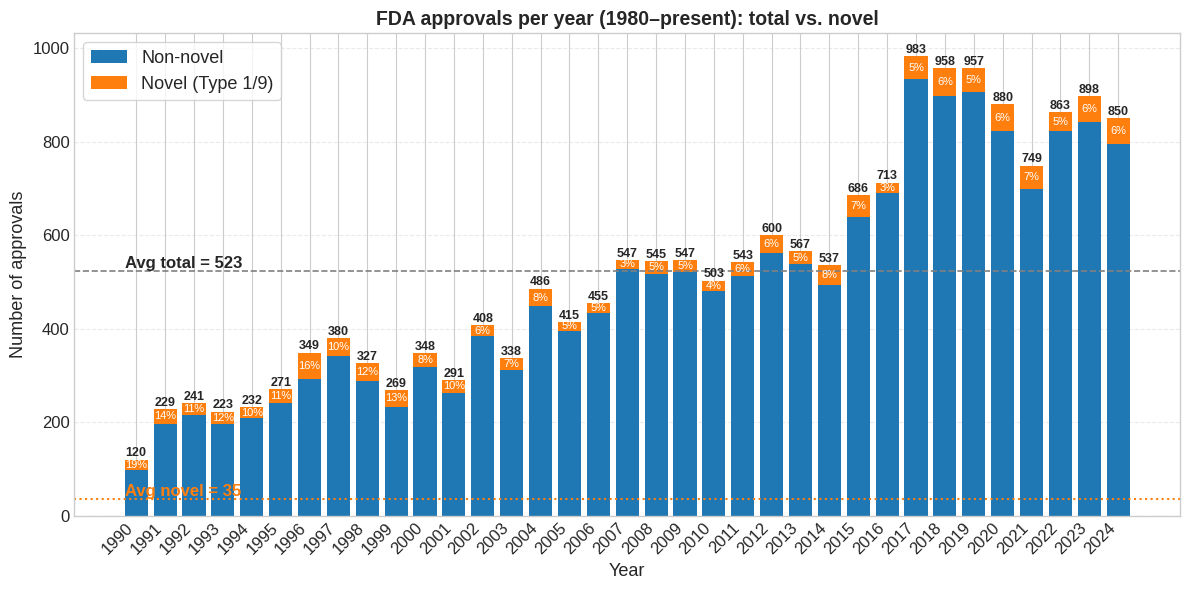

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure dtypes ---
df_all["year"] = pd.to_numeric(df_all["year"], errors="coerce").astype("Int64")
df_all["is_novel_drug_therapy"] = df_all["is_novel_drug_therapy"].fillna(False).astype(bool)

year_filter = 1990
# --- Filter to 1980+ ---
df_1980 = df_all[df_all["year"] >= year_filter].copy()

# --- Aggregate per year ---
yearly = (
    df_1980.groupby("year")
    .agg(total=("application_number", "size"),
         novel=("is_novel_drug_therapy", "sum"))
    .dropna(subset=["total"])
    .sort_index()
)
yearly["non_novel"] = yearly["total"] - yearly["novel"]

# --- Averages over 1980+ period ---
avg_total = yearly["total"].mean()
avg_novel = yearly["novel"].mean()

# --- Prep arrays for plotting (use positional x to avoid dtype issues) ---
years = yearly.index.astype("int64").to_numpy()
x = np.arange(len(years))
total = yearly["total"].to_numpy()
non_novel = yearly["non_novel"].to_numpy()
novel = yearly["novel"].to_numpy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bars
ax.bar(x, non_novel, label="Non-novel")
ax.bar(x, novel, bottom=non_novel, label="Novel (Type 1/9)")

# Total numbers on top of each bar
for xi, tot in zip(x, total):
    ax.text(xi, tot + 0.5, f"{int(tot)}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Novel proportion (%) inside the novel segment
for xi, base, nv, tot in zip(x, non_novel, novel, total):
    if nv > 0 and tot > 0:
        prop = nv / tot
        ax.text(xi, base + nv/2, f"{prop:.0%}", ha="center", va="center", fontsize=8, color="white")

# Average lines (single y-axis)
ax.axhline(avg_total, color="gray", linestyle="--", linewidth=1.2)
ax.text(-0.4, avg_total + 1, f"Avg total = {avg_total:.0f}", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(avg_novel, color="tab:orange", linestyle=":", linewidth=1.5)
ax.text(-0.4, avg_novel + 1, f"Avg novel = {avg_novel:.0f}", va="bottom", color="tab:orange", fontsize=12, fontweight="bold")

# Labels & style
ax.set_title(f"FDA approvals per year ({str(year_filter}–present): total vs. new molecular entities (NMEs)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of approvals", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right")
ax.tick_params(axis="both", labelsize=12)


ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()


## validate DB fetched with website data

In [267]:
website_drugs = pd.read_csv("out/FDA_novel_drug_approvals_2011_2024.csv")
website_drugs["drug_name"] = website_drugs["drug_name"].fillna(website_drugs["active_ingredient"])

website_drugs.shape

(603, 7)

In [268]:
df_novel

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description
0,1970,NDA016721,VALEANT PHARM INTL,DALMANE,ORAL,CAPSULE,"[{'name': 'FLURAZEPAM HYDROCHLORIDE', 'strengt...",19700407,Type 1 - New Molecular Entity
1,1970,NDA016750,AMPHASTAR PHARMS INC,CORTROSYN,INJECTION,INJECTABLE,"[{'name': 'COSYNTROPIN', 'strength': '0.25MG/V...",19700422,Type 1 - New Molecular Entity
2,1970,NDA016769,ORTHO MCNEIL JANSSEN,URISPAS,ORAL,TABLET,"[{'name': 'FLAVOXATE HYDROCHLORIDE', 'strength...",19700115,Type 1 - New Molecular Entity
3,1970,NDA016774,NOVARTIS,SERENTIL,ORAL,TABLET,"[{'name': 'MESORIDAZINE BESYLATE', 'strength':...",19700227,Type 1 - New Molecular Entity
4,1970,NDA016782,SOLVAY,LITHONATE,ORAL,CAPSULE,"[{'name': 'LITHIUM CARBONATE', 'strength': '30...",19700406,Type 1 - New Molecular Entity
...,...,...,...,...,...,...,...,...,...
1555,2024,NDA218860,IPSEN,IQIRVO,ORAL,TABLET,"[{'name': 'ELAFIBRANOR', 'strength': '80MG'}]",20240610,Type 1 - New Molecular Entity
1556,2024,NDA218944,SYNDAX,REVUFORJ,ORAL,TABLET,"[{'name': 'REVUMENIB CITRATE', 'strength': 'EQ...",20241115,Type 1 - New Molecular Entity
1557,2024,NDA219008,JANSSEN BIOTECH,LAZCLUZE,ORAL,TABLET,"[{'name': 'LAZERTINIB MESYLATE', 'strength': '...",20240819,Type 1 - New Molecular Entity
1558,2024,NDA219132,INTRABIO,AQNEURSA,ORAL,FOR SUSPENSION,"[{'name': 'LEVACETYLLEUCINE', 'strength': '1GM...",20240924,Type 1 - New Molecular Entity


In [270]:
import re

def partial_match(name, drug_list):
    if pd.isna(name):
        return None
    name_upper = str(name).upper().strip()
    for drug in drug_list:
        # stricter: match whole token (word boundary), escape special chars
        pat = r'\b' + re.escape(drug) + r'\b'
        if re.search(pat, name_upper):
            return drug
    return None

for year in range(2011, 2025):
    print(f"\nchecking year {year}")
    target_drugs_list = list(website_drugs[website_drugs['year'] == year].drug_name)
    # unique, clean targets
    drug_names_upper = sorted({str(d).upper().strip() for d in target_drugs_list if pd.notna(d)})
    print(f"target drugs {len(drug_names_upper)}")

    df_novel["year"] = pd.to_numeric(df_novel["year"], errors="coerce").astype("Int64")
    df_novel_year = df_novel.loc[df_novel["year"] == year].copy()
    print(f"FDA novel drugs {df_novel_year.shape}")

    # compute matches once
    df_novel_year.loc[:, "brand_norm"] = df_novel_year["brand_name"].astype(str).str.upper().str.strip()
    df_novel_year.loc[:, "matched_drug"] = df_novel_year["brand_norm"].apply(
        lambda x: partial_match(x, drug_names_upper)
    )
    df_matched = df_novel_year.dropna(subset=["matched_drug"])

    print(f"{df_matched['matched_drug'].nunique()} of {len(drug_names_upper)} drugs matched")

    # reference vs found (by canonical target names)
    set_ref = set(drug_names_upper)
    set_found = set(df_matched["matched_drug"].str.upper())
    missing_drugs = sorted(set_ref - set_found)
    print(f"Drugs missing from dataset ({len(missing_drugs)}):")
    for d in missing_drugs:
        print(" -", d)

    # extras = rows that did NOT match any target by partial_match
    df_extras = df_novel_year[df_novel_year["matched_drug"].isna()].copy()
    extra_brands = (
        df_extras.groupby("brand_norm")["submission_class_code_description"]
        .size()
        .reset_index(name="rows")
        .sort_values(["rows", "brand_norm"], ascending=[False, True])
    )

    print(
        f"Extras in FDA dataset not in website list: "
        f"{len(df_extras)} unmatched rows across {len(extra_brands)} unique brands"
    )
    for _, r in extra_brands.iterrows():
        subcls = (
            df_extras.loc[df_extras["brand_norm"] == r["brand_norm"], "submission_class_code_description"]
            .dropna().unique()
        )
        subcls_str = "; ".join(sorted(map(str, subcls))) if len(subcls) else "NA"
        print(f" - {r['brand_norm']}  (rows={r['rows']})  {subcls_str}")



checking year 2011
target drugs 30
FDA novel drugs (31, 9)
29 of 30 drugs matched
Drugs missing from dataset (1):
 - ERWINAZE
Extras in FDA dataset not in website list: 1 unmatched rows across 1 unique brands
 - ZYCLARA  (rows=1)  Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval

checking year 2012
target drugs 39
FDA novel drugs (38, 9)
35 of 39 drugs matched
Drugs missing from dataset (4):
 - BELVIQ
 - CHOLINE C 11 INJECTION
 - FULYZAQ
 - NEUTROVAL
Extras in FDA dataset not in website list: 3 unmatched rows across 3 unique brands
 - CHOLINE C-11  (rows=1)  Type 1 - New Molecular Entity
 - GRANIX  (rows=1)  Type 1 - New Molecular Entity
 - MYTESI  (rows=1)  Type 1 - New Molecular Entity

checking year 2013
target drugs 27
FDA novel drugs (29, 9)
26 of 27 drugs matched
Drugs missing from dataset (1):
 - BRINTELLIX
Extras in FDA dataset not in website list: 3 unmatched rows across 3 unique brands
 - STIVARGA  (rows=1)  Type 9 - New Indica

# Website Scraping

In [200]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin

#url = "https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-2021"
ulr_2015_2020 = "https://web.archive.org/web/20240428045412/https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-{}"
ulr_2021_2024 = "https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-{}"

def extract_table_df(soup, base_url):
    """
    Find the approvals table and build a clean DataFrame.
    - Detects header rows even when <thead> is missing (common in older FDA pages / archives).
    - Skips the header row if it appears in <tbody>.
    - Normalizes column names across years.
    """
    from urllib.parse import urljoin

    # Try known containers
    container_selectors = [
        "#main-content > div > div.table-responsive",
        "#DataTables_Table_0_wrapper",
        "#main-content",
    ]
    container = None
    for sel in container_selectors:
        container = soup.select_one(sel)
        if container:
            break
    if not container:
        raise RuntimeError("Could not find any known table container.")

    # Find a table
    table = container.find("table")
    if not table:
        tables = container.find_all("table")
        if not tables:
            raise RuntimeError("Could not find a <table> inside the detected container.")
        table = tables[0]

    # Helper to normalize text
    def norm(s):
        return " ".join(s.strip().lower().replace("\xa0", " ").split())

    # Known header variants
    expected_headers = [
        ["no.", "drug name", "active ingredient", "approval date", "fda-approved use on approval date*"],
        ["no.", "drug name", "active ingredient", "date", "fda-approved use on approval date*"],
        ["no.", "drug name", "active ingredient", "approval date", "fda-approved use on approval date"],
        ["no.", "drug name", "active ingredient", "date", "fda-approved use on approval date"],
    ]

    # Try <thead> first
    thead_ths = table.select("thead th")
    if thead_ths:
        headers = [th.get_text(" ", strip=True) for th in thead_ths]
        skip_first_body_row = False
    else:
        # No thead: peek first tbody row; if it looks like headers, use it as headers and skip it
        first_tr = table.select_one("tbody tr")
        if not first_tr:
            raise RuntimeError("Table has no header and no body rows.")
        first_cells = [td.get_text(" ", strip=True) for td in first_tr.find_all(["td", "th"])]
        first_norm = [norm(x) for x in first_cells]
        if first_norm in expected_headers:
            headers = first_cells
            skip_first_body_row = True
        else:
            # Fallback: generic headers
            n_cols = len(first_cells)
            headers = [f"col_{i+1}" for i in range(n_cols)]
            skip_first_body_row = False

    # Collect rows + drug links
    rows, drug_links = [], []
    body_rows = table.select("tbody tr")
    if skip_first_body_row and body_rows:
        body_rows = body_rows[1:]  # drop header-like row from data

    for tr in body_rows:
        cells = tr.find_all(["td", "th"])
        if not cells:
            continue
        row_texts = [td.get_text(" ", strip=True) for td in cells]
        # normalize length to headers
        if len(row_texts) < len(headers):
            row_texts += [None] * (len(headers) - len(row_texts))
        elif len(row_texts) > len(headers):
            row_texts = row_texts[:len(headers)]
        rows.append(row_texts)

        # Drug URL typically in 2nd column ("Drug Name")
        a = cells[1].find("a") if len(cells) > 1 else None
        drug_links.append(urljoin(base_url, a["href"]) if a and a.get("href") else None)

    # Build DataFrame
    import pandas as pd
    df = pd.DataFrame(rows, columns=headers)

    # If we still ended up with generic col_1.. but the first data row looks like headers, fix that
    if df.columns[0].startswith("col_"):
        first_norm = [norm(x) for x in df.iloc[0].tolist()]
        if first_norm in expected_headers:
            df.columns = df.iloc[0].tolist()
            df = df.iloc[1:].reset_index(drop=True)

    # Normalize column names across years
    rename_map_candidates = {
        "No.": "no",
        "Drug Name": "drug_name",
        "Active Ingredient": "active_ingredient",
        "Approval Date": "approval_date",
        "Date": "approval_date",
        "FDA-approved use on approval date*": "fda_use_on_approval",
        "FDA-approved use on approval date": "fda_use_on_approval",
        "Drug URL": "drug_url",
    }
    df = df.rename(columns={k: v for k, v in rename_map_candidates.items() if k in df.columns})

    # Attach links
    if len(drug_links) == len(df):
        df["drug_url"] = drug_links

    # Clean up "no"
    if "no" in df.columns:
        df["no"] = (
            df["no"].astype(str).str.strip().str.rstrip(".").replace({"": None})
        )
        # Optional numeric:
        # df["no"] = pd.to_numeric(df["no"], errors="coerce").astype("Int64")

    # Coerce approval_date if present
    if "approval_date" in df.columns:
        df["approval_date"] = pd.to_datetime(df["approval_date"], errors="coerce")

    return df, sel


In [201]:
df_years = []

for year in range(2015, 2025):  # 2015..2023; change to 2025 if you want the latest included
    print(f"\nFetching data for {year}")
    # Choose URL template
    url = (ulr_2015_2020 if year < 2021 else ulr_2021_2024).format(year)

    try:
        resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, "html.parser")

        df, used_selector = extract_table_df(soup, url)
        df["Year"] = year
        print(f"  ✓ Found via: {used_selector or 'fallback'} | shape {df.shape}")
        df_years.append(df)

    except Exception as e:
        print(f"  ✗ Failed for {year}: {e}")

# Combine all years that succeeded
if df_years:
    all_years_df = pd.concat(df_years, ignore_index=True)
    # Optional: normalize column names
    rename_map = {
        "Drug Name": "drug_name",
        "Active Ingredient": "active_ingredient",
        "Approval Date": "approval_date",
        "FDA-approved use on approval date*": "fda_use_on_approval",
        "No.": "no",
        "Drug URL": "drug_url",
        "Year": "year",
    }
    all_years_df = all_years_df.rename(columns={k: v for k, v in rename_map.items() if k in all_years_df.columns})
    print("\nFinal shape:", all_years_df.shape)
else:
    print("\nNo data collected.")


Fetching data for 2015
  ✓ Found via: #main-content > div > div.table-responsive | shape (45, 7)

Fetching data for 2016
  ✓ Found via: #main-content > div > div.table-responsive | shape (22, 7)

Fetching data for 2017
  ✓ Found via: #main-content > div > div.table-responsive | shape (46, 7)

Fetching data for 2018
  ✓ Found via: #main-content > div > div.table-responsive | shape (59, 7)

Fetching data for 2019
  ✓ Found via: #main-content > div > div.table-responsive | shape (48, 7)

Fetching data for 2020
  ✓ Found via: #main-content > div > div.table-responsive | shape (54, 7)

Fetching data for 2021
  ✓ Found via: #main-content > div > div.table-responsive | shape (50, 7)

Fetching data for 2022
  ✓ Found via: #main-content | shape (37, 7)

Fetching data for 2023
  ✓ Found via: #main-content > div > div.table-responsive | shape (55, 7)

Fetching data for 2024
  ✓ Found via: #main-content > div > div.table-responsive | shape (50, 7)

Final shape: (466, 7)


In [202]:
# from https://web.archive.org/web/20240916233346/http://wayback.archive-it.org/7993/20161022052140/http://www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm285554.htm
data = [
    [1, "Eylea", "aflibercept", "2011-11-18", "To treat patients with wet (neovascular) age-related macular degeneration (AMD), a leading cause of vision loss and blindness in Americans ages 60 and older.", None, 2011],
    [2, "Erwinaze", "asparaginase Erwinia chrysanthemi", "2011-11-18", "To treat patients with acute lymphoblastic leukemia (ALL), who have developed an allergy (hypersensitivity) to E. coli derived asparaginase and pegapargase chemotherapy drugs used to treat ALL.", None, 2011],
    [3, "Jakafi", "ruxolitinib", "2011-11-16", "To treat patients with the bone marrow disease myelofibrosis.", None, 2011],
    [4, "Onfi", "clobazam", "2011-10-24", "For use as an adjunctive (add-on) treatment for seizures associated with Lennox-Gastaut syndrome in adults and children 2 years of age and older.", None, 2011],
    [5, "Ferriprox", "deferiprone", "2011-10-14", "To treat patients with iron overload due to blood transfusions in patients with thalassemia, a genetic blood disorder that causes anemia, who had an inadequate response to prior chelation therapy.", None, 2011],
    [6, "Xalkori", "crizotinib", "2011-08-26", "To treat certain patients with late-stage (locally advanced or metastatic), non-small cell lung cancers (NSCLC) who express the abnormal anaplastic lymphoma kinase (ALK) gene.", None, 2011],
    [7, "Firazyr", "icatibant", "2011-08-25", "For the treatment of acute attacks of a rare condition called hereditary angioedema (HAE) in people ages 18 years and older.", None, 2011],
    [8, "Adcetris", "brentuximab vedotin", "2011-08-19", "For the treatment of Hodgkin lymphoma and ALCL (systemic anaplastic large cell lymphoma).", None, 2011],
    [9, "Zelboraf", "vemurafenib", "2011-08-17", "To treat patients with late-stage (metastatic) or unresectable (cannot be removed by surgery) melanoma, the most dangerous type of skin cancer.", None, 2011],
    [10, "Brilinta", "ticagrelor", "2011-07-20", "To reduce cardiovascular death and heart attack in patients with acute coronary syndromes (ACS).", None, 2011],
    [11, "Xarelto", "rivaroxaban", "2011-07-01", "To reduce the risk of blood clots, deep vein thrombosis (DVT), and pulmonary embolism (PE) following knee or hip replacement surgery.", None, 2011],
    [12, "Arcapta Neohaler", "indacaterol inhalation powder", "2011-07-01", "For the long term, once-daily maintenance bronchodilator treatment of airflow obstruction in people with chronic obstructive pulmonary disease (COPD) including chronic bronchitis and/or emphysema.", None, 2011],
    [13, "Nulojix", "belatacept", "2011-06-15", "To prevent acute rejection in adult patients who have had a kidney transplant.", None, 2011],
    [14, "Potiga", "ezogabine", "2011-06-10", "For use as an add-on medication to treat seizures associated with epilepsy in adults.", None, 2011],
    [15, "Dificid", "fidaxomicin", "2011-05-27", "For the treatment of Clostridium difficile-associated diarrhea (CDAD).", None, 2011],
    [16, "Incivek", "telaprevir", "2011-05-23", "To treat certain adults with chronic hepatitis C infection.", None, 2011],
    [17, "Edurant", "rilpivirine", "2011-05-20", "For the treatment of HIV-1 infection in adults who have never taken HIV therapy.", None, 2011],
    [18, "Victrelis", "boceprevir", "2011-05-13", "To treat certain adults with chronic hepatitis C.", None, 2011],
    [19, "Tradjenta", "linagliptin", "2011-05-02", "An adjunct to diet and exercise to improve glycemic control in adults with type 2 diabetes mellitus.", None, 2011],
    [20, "Zytiga", "abiraterone acetate", "2011-04-28", "In combination with prednisone (a steroid) to treat patients with late-stage (metastatic) castration-resistant prostate cancer who have received prior docetaxel (chemotherapy).", None, 2011],
    [21, "Caprelsa", "vandetanib", "2011-04-06", "To treat adult patients with late-stage (metastatic) medullary thyroid cancer who are ineligible for surgery and who have disease that is growing or causing symptoms.", None, 2011],
    [22, "Horizant", "gabapentin enacarbil", "2011-04-06", "A once-daily treatment for moderate-to-severe restless legs syndrome (RLS).", None, 2011],
    [23, "Yervoy", "ipilimumab", "2011-03-25", "To treat patients with late-stage (metastatic) melanoma, the most dangerous type of skin cancer.", None, 2011],
    [24, "Gadavist", "gadobutrol", "2011-03-14", "For use in patients undergoing magnetic resonance imaging (MRI) of the central nervous system.", None, 2011],
    [25, "Benlysta", "belimumab", "2011-03-09", "To treat patients with active, autoantibody-positive lupus (systemic lupus erythematosus) who are receiving standard therapy, including corticosteroids, antimalarials, immunosuppressives, and nonsteroidal anti-inflammatory drugs.", None, 2011],
    [26, "Daliresp", "roflumilast", "2011-02-28", "To decrease the frequency of flare-ups (exacerbations) or worsening of symptoms from severe chronic obstructive pulmonary disease (COPD).", None, 2011],
    [27, "Edarbi", "azilsartan medoxomil", "2011-02-25", "To treat high blood pressure (hypertension) in adults.", None, 2011],
    [28, "Viibryd", "vilazodone hydrochloride", "2011-01-21", "To treat major depressive disorder in adults.", None, 2011],
    [29, "Natroba", "spinosad", "2011-01-18", "For the treatment of head lice infestation in patients ages 4 years and older.", None, 2011],
    [30, "Datscan", "ioflupane i-123", "2011-01-14", "An imaging drug used to assist in the evaluation of adult patients with suspected Parkinsonian syndromes (PS).", None, 2011]
]

df_2011 = pd.DataFrame(
    data,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)

In [203]:
# from https://web.archive.org/web/20240917025003/https://wayback.archive-it.org/7993/20161022052138/http:/www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm336115.htm
data_2012 = [
    [39, "Fulyzaq", "crofelemer", "2012-12-31", "To treat HIV/AIDS patients whose diarrhea is not caused by an infection from a virus, bacteria, or parasite.", None, 2012],
    [38, "Sirturo", "bedaquiline", "2012-12-28", "As part of combination therapy to treat adults with multi-drug resistant pulmonary tuberculosis (TB) when other alternatives are not available.", None, 2012],
    [37, "Eliquis", "apixaban", "2012-12-28", "To reduce the risk of stroke and dangerous blood clots (systemic embolism) in patients with atrial fibrillation that is not caused by a heart valve problem.", None, 2012],
    [36, "Juxtapid", "lomitapide", "2012-12-21", "To reduce low-density lipoprotein (LDL) cholesterol, total cholesterol, apolipoprotein B, and non-high-density lipoprotein (non-HDL) cholesterol in patients with homozygous familial hypercholesterolemia (HoFH).", None, 2012],
    [35, "Gattex", "teduglutide", "2012-12-21", "To treat adults with short bowel syndrome (SBS) who need additional nutrition from intravenous feeding (parenteral nutrition).", None, 2012],
    [34, "Signifor", "pasereotide", "2012-12-14", "To treat Cushing’s disease patients who cannot be helped through surgery.", None, 2012],
    [33, "Raxibacumab", "raxibacumab", "2012-12-14", "To treat inhalational anthrax, a form of the infectious disease caused by breathing in the spores of Bacillus anthracis.", None, 2012],
    [32, "Iclusig", "ponatinib", "2012-12-14", "To treat adults with chronic myeloid leukemia (CML) and Philadelphia chromosome positive acute lymphoblastic leukemia (Ph+ ALL).", None, 2012],
    [31, "Cometriq", "cabozantinib", "2012-11-29", "To treat medullary thyroid cancer that has spread to other parts of the body (metastasized).", None, 2012],
    [30, "Xeljanz", "tofacitinib", "2012-11-06", "To treat adults with moderately to severely active rheumatoid arthritis (RA) who have had an inadequate response to or intolerance of methotrexate.", None, 2012],
    [29, "Synribo", "omacetaxine mepesuccinate", "2012-10-26", "To treat adults with chronic myelogenous leukemia (CML), a blood and bone marrow disease.", None, 2012],
    [28, "Fycompa", "perampanel", "2012-10-22", "To treat partial onset seizures in patients with epilepsy ages 12 years and older.", None, 2012],
    [27, "Jetrea", "ocriplasmin", "2012-10-17", "To treat an eye condition called symptomatic vitreomacular adhesion (VMA).", None, 2012],
    [26, "Stivarga", "regorafenib", "2012-09-27", "To treat patients with colorectal cancer that has progressed after treatment and spread to other parts of the body (metastatic).", None, 2012],
    [25, "Choline C 11 Injection", "Choline C 11 Injection", "2012-09-12", "A Positron Emission Tomography (PET) imaging agent used to help detect recurrent prostate cancer.", None, 2012],
    [24, "Aubagio", "teriflunomide", "2012-09-12", "For the treatment of adults with relapsing forms of multiple sclerosis (MS).", None, 2012],
    [23, "Bosulif", "bosutinib", "2012-09-04", "To treat chronic myelogenous leukemia (CML), a blood and bone marrow disease that usually affects older adults.", None, 2012],
    [22, "Xtandi", "enzalutamide", "2012-08-31", "To treat men with late-stage (metastatic) castration-resistant prostate cancer that has spread or recurred.", None, 2012],
    [21, "Linzess", "linaclotide", "2012-08-30", "To treat chronic idiopathic constipation and irritable bowel syndrome with constipation (IBS-C) in adults.", None, 2012],
    [20, "Neutroval", "tbo-filgrastim", "2012-08-29", "To reduce the time certain patients receiving cancer chemotherapy experience severe neutropenia, a decrease in infection-fighting white blood cells.", None, 2012],
    [19, "Stribild", "elvitegravir, cobicistat, emtricitabine, tenofovir disoproxil fumarate", "2012-08-27", "A once-daily combination pill to treat HIV-1 infection in adults who have never been treated for HIV infection.", None, 2012],
    [18, "Zaltrap", "ziv-aflibercept", "2012-08-03", "For use in combination with FOLFIRI chemotherapy to treat adults with colorectal cancer.", None, 2012],
    [17, "Tudorza Pressair", "aclidinium bromide", "2012-07-23", "For the long-term maintenance treatment of bronchospasm associated with chronic obstructive pulmonary disease (COPD).", None, 2012],
    [16, "Kyprolis", "carfilzomib", "2012-07-20", "To treat patients with multiple myeloma who have received at least two prior therapies.", None, 2012],
    [15, "Prepopik", "sodium picosulfate, magnesium oxide and citric acid", "2012-07-16", "To help cleanse the colon in adults preparing for colonoscopy.", None, 2012],
    [14, "Myrbetriq", "mirabegron", "2012-06-28", "To treat adults with overactive bladder.", None, 2012],
    [13, "Belviq", "lorcaserin hydrochloride", "2012-06-27", "For chronic weight management.", None, 2012],
    [12, "Perjeta", "pertuzumab", "2012-06-08", "To treat patients with HER2-positive late-stage (metastatic) breast cancer.", None, 2012],
    [11, "Elelyso", "taliglucerase alfa", "2012-05-01", "For long-term enzyme replacement therapy to treat a form of Gaucher disease.", None, 2012],
    [10, "Stendra", "avanafil", "2012-04-27", "To treat erectile dysfunction.", None, 2012],
    [9, "Amyvid", "Florbetapir F 18", "2012-04-06", "Used as a radioactive diagnostic agent for PET brain imaging to estimate β-amyloid plaque density in adults with cognitive impairment.", None, 2012],
    [8, "Omontys", "peginesatide", "2012-03-27", "To treat anemia in adult dialysis patients who have chronic kidney disease (CKD).", None, 2012],
    [7, "Surfaxin", "lucinactant", "2012-03-06", "For the prevention of respiratory distress syndrome (RDS) in premature infants.", None, 2012],
    [6, "Zioptan", "tafluprost", "2012-02-10", "For reducing elevated intraocular pressure in patients with open-angle glaucoma or ocular hypertension.", None, 2012],
    [5, "Kalydeco", "ivacaftor", "2012-01-31", "For the treatment of a rare form of cystic fibrosis (CF) in patients ages 6 years and older with the G551D mutation.", None, 2012],
    [4, "Erivedge", "vismodegib", "2012-01-30", "To treat adult patients with basal cell carcinoma, the most common type of skin cancer.", None, 2012],
    [3, "Inlyta", "axitinib", "2012-01-27", "To treat patients with advanced kidney cancer (renal cell carcinoma) who have not responded to other drugs.", None, 2012],
    [2, "Picato", "ingenol mebutate", "2012-01-23", "For the topical treatment of actinic keratosis.", None, 2012],
    [1, "Voraxaze", "glucarpidase", "2012-01-17", "To treat patients with toxic levels of methotrexate in their blood due to kidney failure.", None, 2012]
]

df_2012 = pd.DataFrame(
    data_2012,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)

In [204]:
# from https://wayback.archive-it.org/7993/20161022052135/http://www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm381263.htm
data_2013 = [
    [27, "Anoro Ellipta", "umeclidinium and vilanterol inhalation powder", "2013-12-18", "For the once-daily, long-term maintenance treatment of airflow obstruction in patients with chronic obstructive pulmonary disease (COPD).", None, 2013],
    [26, "Sovaldi", "sofosbuvir", "2013-12-06", "To treat chronic hepatitis C virus (HCV) infection.", None, 2013],
    [25, "Olysio", "simeprevir", "2013-11-22", "To treat chronic hepatitis C virus infection.", None, 2013],
    [24, "Luzu", "luliconozole", "2013-11-14", "For the topical treatment of interdigital tinea pedis, tinea cruris, and tinea corporis caused by Trichophyton rubrum and Epidermophyton floccosum, in patients 18 years and older.", None, 2013],
    [23, "Imbruvica", "ibrutinib", "2013-11-13", "To treat patients with mantle cell lymphoma (MCL), a rare and aggressive type of blood cancer.", None, 2013],
    [22, "Aptiom", "eslicarbazepine acetate", "2013-11-08", "As an add-on medication to treat seizures associated with epilepsy.", None, 2013],
    [21, "Gazyva", "obinutuzumab", "2013-11-01", "For use in combination with chlorambucil to treat patients with previously untreated chronic lymphocytic leukemia (CLL).", None, 2013],
    [20, "Vizamyl", "flutemetamol F 18 injection", "2013-10-25", "A radioactive diagnostic drug for PET imaging of the brain in adults being evaluated for Alzheimer’s disease and dementia.", None, 2013],
    [19, "Opsumit", "macitentan", "2013-10-18", "To treat adults with pulmonary arterial hypertension (PAH), a chronic, progressive and debilitating disease.", None, 2013],
    [18, "Adempas", "riociguat", "2013-10-08", "To treat adults with two forms of pulmonary hypertension.", None, 2013],
    [17, "Duavee", "conjugated estrogens/bazedoxifene", "2013-10-03", "To treat moderate-to-severe hot flashes associated with menopause and to prevent osteoporosis after menopause.", None, 2013],
    [16, "Brintellix", "vortioxetine", "2013-09-30", "To treat adults with major depressive disorder.", None, 2013],
    [15, "Tivicay", "dolutegravir", "2013-08-12", "To treat HIV-1 infection.", None, 2013],
    [14, "Gilotrif", "afatinib", "2013-07-12", "For patients with late-stage non-small cell lung cancer (NSCLC) whose tumors express specific EGFR gene mutations.", None, 2013],
    [13, "Mekinist", "trametinib", "2013-05-29", "To treat patients whose tumors express the BRAF V600E or V600K gene mutations.", None, 2013],
    [12, "Tafinlar", "dabrafenib", "2013-05-29", "To treat patients with melanoma whose tumors express the BRAF V600E gene mutation.", None, 2013],
    [11, "Xofigo", "radium Ra 223 dichloride", "2013-05-15", "To treat men with symptomatic late-stage castration-resistant prostate cancer that has spread to bones but not to other organs.", None, 2013],
    [10, "Breo Ellipta", "fluticasone furoate and vilanterol inhalation powder", "2013-05-10", "For the long-term, once-daily maintenance treatment of airflow obstruction in patients with COPD, including chronic bronchitis and/or emphysema.", None, 2013],
    [9, "Invokana", "canagliflozin", "2013-03-29", "Used with diet and exercise to improve glycemic control in adults with type 2 diabetes.", None, 2013],
    [8, "Tecfidera", "dimethyl fumarate", "2013-03-27", "To treat adults with relapsing forms of multiple sclerosis (MS).", None, 2013],
    [7, "Dotarem", "gadoterate meglumine", "2013-03-20", "For use in MRI of the brain, spine, and associated tissues of patients ages 2 years and older.", None, 2013],
    [6, "Lymphoseek", "technetium Tc 99m tilmanocept", "2013-03-13", "A radioactive diagnostic imaging agent that helps doctors locate lymph nodes in patients with breast cancer or melanoma undergoing surgery.", None, 2013],
    [5, "Osphena", "ospemifene", "2013-02-26", "To treat women experiencing moderate to severe dyspareunia (pain during sexual intercourse), a symptom of vulvar and vaginal atrophy due to menopause.", None, 2013],
    [4, "Kadcyla", "ado-trastuzumab emtansine", "2013-02-22", "For patients with HER2-positive, late-stage (metastatic) breast cancer.", None, 2013],
    [3, "Pomalyst", "pomalidomide", "2013-02-08", "To treat patients with multiple myeloma whose disease progressed after being treated with other cancer drugs.", None, 2013],
    [2, "Kynamro", "mipomersen sodium", "2013-01-29", "To treat patients with a rare type of high cholesterol called homozygous familial hypercholesterolemia (HoFH).", None, 2013],
    [1, "Nesina", "alogliptin", "2013-01-25", "To improve blood sugar control in adults with type 2 diabetes.", None, 2013],
]

df_2013 = pd.DataFrame(
    data_2013,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)


In [205]:
# from https://wayback.archive-it.org/7993/20161022052129/http://www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm429247.htm
data_2014 = [
    [41, "Opdivo", "nivolumab", "2014-12-22", "To treat patients with unresectable (cannot be removed by surgery) or metastatic melanoma who no longer respond to other drugs.", None, 2014],
    [40, "Rapivab", "peramivir", "2014-12-19", "To treat influenza infection in adults.", None, 2014],
    [39, "Zerbaxa", "ceftolozane/tazobactam", "2014-12-19", "To treat adults with complicated intra-abdominal infections (cIAI) and complicated urinary tract infections (cUTI).", None, 2014],
    [38, "Viekira Pak", "ombitasvir, paritaprevir, ritonavir, dasabuvir", "2014-12-19", "To treat patients with chronic hepatitis C virus (HCV) genotype 1 infection, including those with cirrhosis.", None, 2014],
    [37, "Lynparza", "olaparib", "2014-12-19", "To treat advanced ovarian cancer.", None, 2014],
    [36, "Xtoro", "finafloxacin otic suspension", "2014-12-17", "To treat acute otitis externa, commonly known as swimmer’s ear.", None, 2014],
    [35, "Blincyto", "blinatumomab", "2014-12-03", "To treat patients with Philadelphia chromosome-negative precursor B-cell acute lymphoblastic leukemia (B-cell ALL).", None, 2014],
    [34, "Esbriet", "pirfenidone", "2014-10-15", "For the treatment of idiopathic pulmonary fibrosis (IPF).", None, 2014],
    [33, "Ofev", "nintedanib", "2014-10-15", "For the treatment of idiopathic pulmonary fibrosis (IPF).", None, 2014],
    [32, "Lumason", "sulfur hexafluoride lipid microsphere", "2014-10-10", "For patients whose ultrasound image of the heart (echocardiograms) are hard to see with ultrasound waves.", None, 2014],
    [31, "Akynzeo", "netupitant and palonosetron", "2014-10-10", "To treat nausea and vomiting in patients undergoing cancer chemotherapy.", None, 2014],
    [30, "Harvoni", "ledipasvir/sofosbuvir", "2014-10-10", "To treat chronic hepatitis C virus (HCV) genotype 1 infection.", None, 2014],
    [29, "Trulicity", "dulaglutide", "2014-09-18", "To treat adults with type 2 diabetes.", None, 2014],
    [28, "Movantik", "naloxegol", "2014-09-16", "To treat opioid-induced constipation in adults with chronic non-cancer pain.", None, 2014],
    [27, "Keytruda", "pembrolizumab", "2014-09-04", "For treatment of patients with advanced or unresectable melanoma who are no longer responding to other drugs.", None, 2014],
    [26, "Cerdelga", "eliglustat", "2014-08-19", "For the long-term treatment of adult patients with the Type 1 form of Gaucher disease.", None, 2014],
    [25, "Plegridy", "peginterferon beta-1a", "2014-08-15", "For the treatment of patients with relapsing forms of multiple sclerosis.", None, 2014],
    [24, "Belsomra", "suvorexant", "2014-08-13", "To treat difficulty in falling and staying asleep (insomnia).", None, 2014],
    [23, "Orbactiv", "oritavancin", "2014-08-06", "To treat adults with skin infections.", None, 2014],
    [22, "Jardiance", "empagliflozin", "2014-08-01", "To improve glycemic control in adults with type 2 diabetes.", None, 2014],
    [21, "Striverdi Respimat", "olodaterol", "2014-07-31", "To treat chronic obstructive pulmonary disease (COPD).", None, 2014],
    [20, "Zydelig", "idelalisib", "2014-07-23", "To treat patients with three types of blood cancers.", None, 2014],
    [19, "Kerydin", "tavaborole", "2014-07-07", "For the topical treatment of onychomycosis of the toenails.", None, 2014],
    [18, "Beleodaq", "belinostat", "2014-07-03", "To treat patients with peripheral T-cell lymphoma (PTCL).", None, 2014],
    [17, "Sivextro", "tedizolid phosphate", "2014-06-20", "To treat adults with skin infections.", None, 2014],
    [16, "Jublia", "efinaconazole", "2014-06-06", "To treat mild to moderate onychomycosis (fungal infection).", None, 2014],
    [15, "Dalvance", "dalbavancin", "2014-05-23", "To treat adults with skin infections.", None, 2014],
    [14, "Entyvio", "vedolizumab", "2014-05-20", "To treat adult patients with moderate to severe ulcerative colitis and moderate to severe Crohn’s disease.", None, 2014],
    [13, "Zontivity", "vorapaxar", "2014-05-08", "To reduce the risk of heart attacks and stroke in high-risk patients.", None, 2014],
    [12, "Zykadia", "ceritinib", "2014-04-29", "To treat patients with a certain type of late-stage (metastatic) non-small cell lung cancer (NSCLC).", None, 2014],
    [11, "Sylvant", "siltuximab", "2014-04-23", "To treat patients with multicentric Castleman’s disease (MCD), a rare disorder similar to lymphoma.", None, 2014],
    [10, "Cyramza", "ramucirumab", "2014-04-21", "To treat patients with advanced stomach cancer or gastroesophageal junction adenocarcinoma.", None, 2014],
    [9, "Tanzeum", "albiglutide", "2014-04-15", "To improve glycemic control, along with diet and exercise, in adults with type 2 diabetes.", None, 2014],
    [8, "Otezla", "apremilast", "2014-03-21", "To treat adults with active psoriatic arthritis (PsA).", None, 2014],
    [7, "Impavido", "miltefosine", "2014-03-19", "To treat a tropical disease called leishmaniasis.", None, 2014],
    [6, "Neuraceq", "florbetaben F 18 injection", "2014-03-19", "For positron emission tomography (PET) imaging of the brain.", None, 2014],
    [5, "Myalept", "metreleptin for injection", "2014-02-24", "To treat the complications of leptin deficiency.", None, 2014],
    [4, "Northera", "droxidopa", "2014-02-18", "To treat neurogenic orthostatic hypotension (NOH).", None, 2014],
    [3, "Vimizim", "elosulfase alfa", "2014-02-14", "Treatment for Mucopolysaccharidosis Type IVA (Morquio A syndrome).", None, 2014],
    [2, "Hetlioz", "tasimelteon", "2014-01-31", "To treat non-24-hour sleep-wake disorder (“non-24”) in totally blind individuals.", None, 2014],
    [1, "Farxiga", "dapagliflozin", "2014-01-08", "To improve glycemic control, along with diet and exercise, in adults with type 2 diabetes.", None, 2014],
]

df_2014 = pd.DataFrame(
    data_2014,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)

In [206]:
# Merge older manually created datasets into existing all_years_df
all_years_df = pd.concat(
    [all_years_df, df_2011, df_2012, df_2013, df_2014],
    ignore_index=True
)

# Ensure consistent types and formatting
all_years_df["year"] = all_years_df["year"].astype(int)
all_years_df["no"] = pd.to_numeric(all_years_df["no"], errors="coerce")


In [207]:
all_years_df.head()

,no,drug_name,active_ingredient,approval_date,fda_use_on_approval,drug_url,year
0,45.0,Zurampic,lesinurad,2015-12-22 00:00:00,To treat high blood uric acid levels associate...,https://web.archive.org/web/20240428045412/htt...,2015
1,44.0,Uptravi,selexipag,2015-12-21 00:00:00,To treat pulmonary arterial hypertension Drug ...,https://web.archive.org/web/20240428045412/htt...,2015
2,43.0,Bridion,sugammadex,2015-12-15 00:00:00,To reverse effects of neuromuscular blocking d...,https://web.archive.org/web/20240428045412/htt...,2015
3,42.0,Alecensa,alectinib,2015-12-11 00:00:00,To treat ALK-positive lung cancer Drug Trials ...,https://web.archive.org/web/20240428045412/htt...,2015
4,41.0,Kanuma,sebelipase alfa,2015-12-08 00:00:00,To treat patients with a rare disease known as...,https://web.archive.org/web/20240428045412/htt...,2015


In [208]:
# Replace empty strings or NaN in drug_name with active_ingredient
all_years_df["drug_name"] = all_years_df["drug_name"].replace("", pd.NA)
all_years_df["drug_name"] = all_years_df["drug_name"].fillna(all_years_df["active_ingredient"])


In [209]:
all_years_df.shape

(603, 7)

In [210]:
all_years_df.drug_name.nunique(), all_years_df.active_ingredient.nunique()

(601, 602)

In [211]:
all_years_df.to_csv("out/FDA_novel_drug_approvals_2011_2024.csv",index=False)

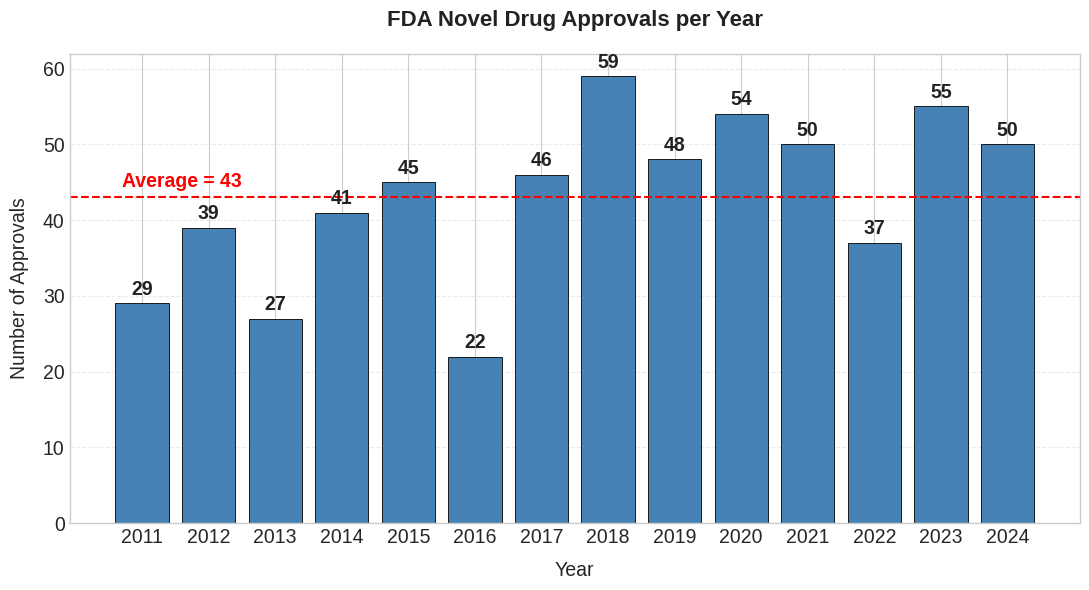

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

# assuming your final dataframe is named all_years_df

# --- Prepare data ---
approvals_per_year = (
    all_years_df.groupby("year")
    .size()
    .reset_index(name="num_approvals")
    .sort_values("year")
)

avg_approvals = approvals_per_year["num_approvals"].mean()

# --- Plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

# Bars — uniform professional blue
bars = ax.bar(
    approvals_per_year["year"],
    approvals_per_year["num_approvals"],
    color="#4682B4",   # steel blue
    edgecolor="black",
    linewidth=0.6
)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.6,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color="#222222"
    )

# Average line + label
ax.axhline(avg_approvals, color="red", linestyle="--", linewidth=1.5)
ax.text(
    approvals_per_year["year"].min() - 0.3,
    avg_approvals + 0.8,
    f"Average = {avg_approvals:.0f}",
    color="red",
    fontsize=14,
    fontweight="bold",
    va="bottom"
)

# Titles and labels
ax.set_title(
    "FDA Novel Drug Approvals per Year",
    fontsize=16,
    fontweight="bold",
    color="#222222",
    pad=20
)
ax.set_xlabel("Year", fontsize=14, labelpad=10)
ax.set_ylabel("Number of Approvals", fontsize=14, labelpad=10)

# Gridlines and ticks
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xticks(approvals_per_year["year"])
ax.set_xticklabels(approvals_per_year["year"])
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.show()
